# CSE 445 — Computer Vision
## Part B — Notebook 2a: BYOL Pretraining on the KIIT-MiTA SSL Pool

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA (Military Target Detection) |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Model** | BYOL Pretrain |



### BYOL (Bootstrap Your Own Latent)

BYOL learns visual representations without labels and without negative pairs. Two networks share the
same architecture: an **online** network (trained by gradient descent) and a **target** network (an
exponential moving average of the online network's weights). Two augmented views of the same image are
fed to the online and target networks respectively; the online network's predictor tries to match the
target network's projection of the other view. Because the target network never receives gradients and
only drifts slowly via EMA, the two branches stay different enough that the model cannot trivially
collapse to a constant output — in principle. This notebook pretrains a YOLOv26n backbone with BYOL on
the unlabelled 80% SSL pool, then Notebook 2b transfers the learned backbone into a detector and
fine-tunes it at a 20% label budget.

---
- Pretrains a BYOL backbone on YOLOv26n using `ssldet`, on the unlabelled SSL pool (labels discarded).
- Plots the SSL loss + target-momentum curves, extracts validation features, runs t-SNE +
   nearest-neighbour diagnostics, a shortcut-learning check on the train pool, and quantitative
   collapse checks (pairwise similarity distribution, embedding effective rank).

## 1. Install `ssldet` and imports

In [1]:
%pip install -q --upgrade "git+https://github.com/rifat963/ssl-detection-lab.git@main" scikit-learn seaborn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from packaging.version import Version
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from ultralytics import YOLO

import ssldet
from ssldet import PretrainConfig, launch_distributed_pretrain
from ssldet.backbones import YOLOBackboneEncoder
from ssldet.data import IMAGENET_MEAN, IMAGENET_STD, UnlabeledImageDataset, build_transform
from ssldet.ssl import create_ssl_module

random.seed(0); np.random.seed(0); torch.manual_seed(0); torch.cuda.manual_seed_all(0)
torch.set_float32_matmul_precision("high")
sns.set_theme(style="whitegrid", context="notebook")

REQUIRED_SSLDET_VERSION = "0.8.1"
assert Version(ssldet.__version__) >= Version(REQUIRED_SSLDET_VERSION), (
    f"ssldet {ssldet.__version__} found, need >= {REQUIRED_SSLDET_VERSION}. "
    "Restart the kernel/session and rerun the install cell from the top, then re-run this cell."
)
print("ssl-detection-lab version:", ssldet.__version__)
assert torch.cuda.is_available(), "Select a GPU accelerator before continuing."

GPU_COUNT = torch.cuda.device_count()
DEVICE = torch.device("cuda:0")
print("GPUs:", GPU_COUNT)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
GPUs: 2


## 2. Attach the Part B data-prep output (partition + SSL pool, already built)

In [3]:
import pathlib, json, yaml

_manifest_candidates = list(pathlib.Path("/kaggle/input").rglob("partition_manifest.json"))
if not _manifest_candidates:
    raise FileNotFoundError(
        "No partition_manifest.json found under /kaggle/input. "
        "Attach group02-partB-00-data-prep's output as an input to this notebook."
    )
PARTITION_MANIFEST_PATH = _manifest_candidates[0]
partition_manifest = json.loads(PARTITION_MANIFEST_PATH.read_text())
BASE_DIR = PARTITION_MANIFEST_PATH.parent

SEED = partition_manifest["seed"]
CLASS_NAMES = partition_manifest["class_names"]
NUM_CLASSES = len(CLASS_NAMES)
TARGET_RATIO = partition_manifest["target_ratio_copy_paste"]

RESPLIT_ROOT = BASE_DIR / "dataset-resplit"
SSL_POOL_TRAIN_DIR = RESPLIT_ROOT / "train" / "images"
SSL_POOL_VAL_DIR = RESPLIT_ROOT / "val" / "images"
SSL_POOL_TEST_DIR = RESPLIT_ROOT / "test" / "images"

for d in [SSL_POOL_TRAIN_DIR, SSL_POOL_VAL_DIR, SSL_POOL_TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Expected directory missing: {d}")

stems_train = partition_manifest["stems_ssl_pool_raw"]
stems_val = partition_manifest["stems_val"]
stems_test = partition_manifest["stems_test"]

print("SSL pool (train) dir:", SSL_POOL_TRAIN_DIR, "| raw stems:", len(stems_train))
print("Val dir             :", SSL_POOL_VAL_DIR, "| stems:", len(stems_val))
print("Test dir            :", SSL_POOL_TEST_DIR, "| stems:", len(stems_test))
print("Classes:", CLASS_NAMES)

SSL pool (train) dir: /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/train/images | raw stems: 1339
Val dir             : /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/val/images | stems: 164
Test dir            : /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/test/images | stems: 178
Classes: ['Artilary', 'Missile', 'Radar', 'M. Rocket Launcher', 'Soldier', 'Tank', 'Vehicle']


## 3. Inspect the dataset

Total image counts per split (raw stems vs. what actually sits on disk — the train folder additionally
contains copy-paste synthetic images), a per-class instance-count table across all three splits, and a
sample grid of raw training images.


In [4]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def image_files(directory):
    return sorted(p for p in Path(directory).rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES)

train_images = image_files(SSL_POOL_TRAIN_DIR)
val_images = image_files(SSL_POOL_VAL_DIR)
test_images = image_files(SSL_POOL_TEST_DIR)

pd.Series({
    "train — raw stems (pre copy-paste)": len(stems_train),
    "train — on disk (raw + copy-paste)": len(train_images),
    "train — copy-paste synthetic added": len(train_images) - len(stems_train),
    "val — on disk (always raw, never augmented)": len(val_images),
    "test — on disk (always raw, never augmented)": len(test_images),
    "TOTAL images on disk (train + val + test)": len(train_images) + len(val_images) + len(test_images),
})

train — raw stems (pre copy-paste)              1339
train — on disk (raw + copy-paste)              2377
train — copy-paste synthetic added              1038
val — on disk (always raw, never augmented)      164
test — on disk (always raw, never augmented)     178
TOTAL images on disk (train + val + test)       2719
dtype: int64

In [5]:
def count_class_instances(labels_dir):
    counts = Counter()
    for lbl_path in Path(labels_dir).glob("*.txt"):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return counts

train_label_counts = count_class_instances(RESPLIT_ROOT / "train" / "labels")
val_label_counts = count_class_instances(RESPLIT_ROOT / "val" / "labels")
test_label_counts = count_class_instances(RESPLIT_ROOT / "test" / "labels")

class_table = pd.DataFrame({
    "train (raw+copy-paste)": [train_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "val": [val_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "test": [test_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
}, index=CLASS_NAMES)
class_table["total"] = class_table.sum(axis=1)
class_table.index.name = "class name"
class_table

,train (raw+copy-paste),val,test,total
class name,,,,
Artilary,610,29,28,667
Missile,764,40,45,849
Radar,772,33,29,834
M. Rocket Launcher,705,33,36,774
Soldier,937,113,92,1142
Tank,824,81,94,999
Vehicle,1033,93,159,1285


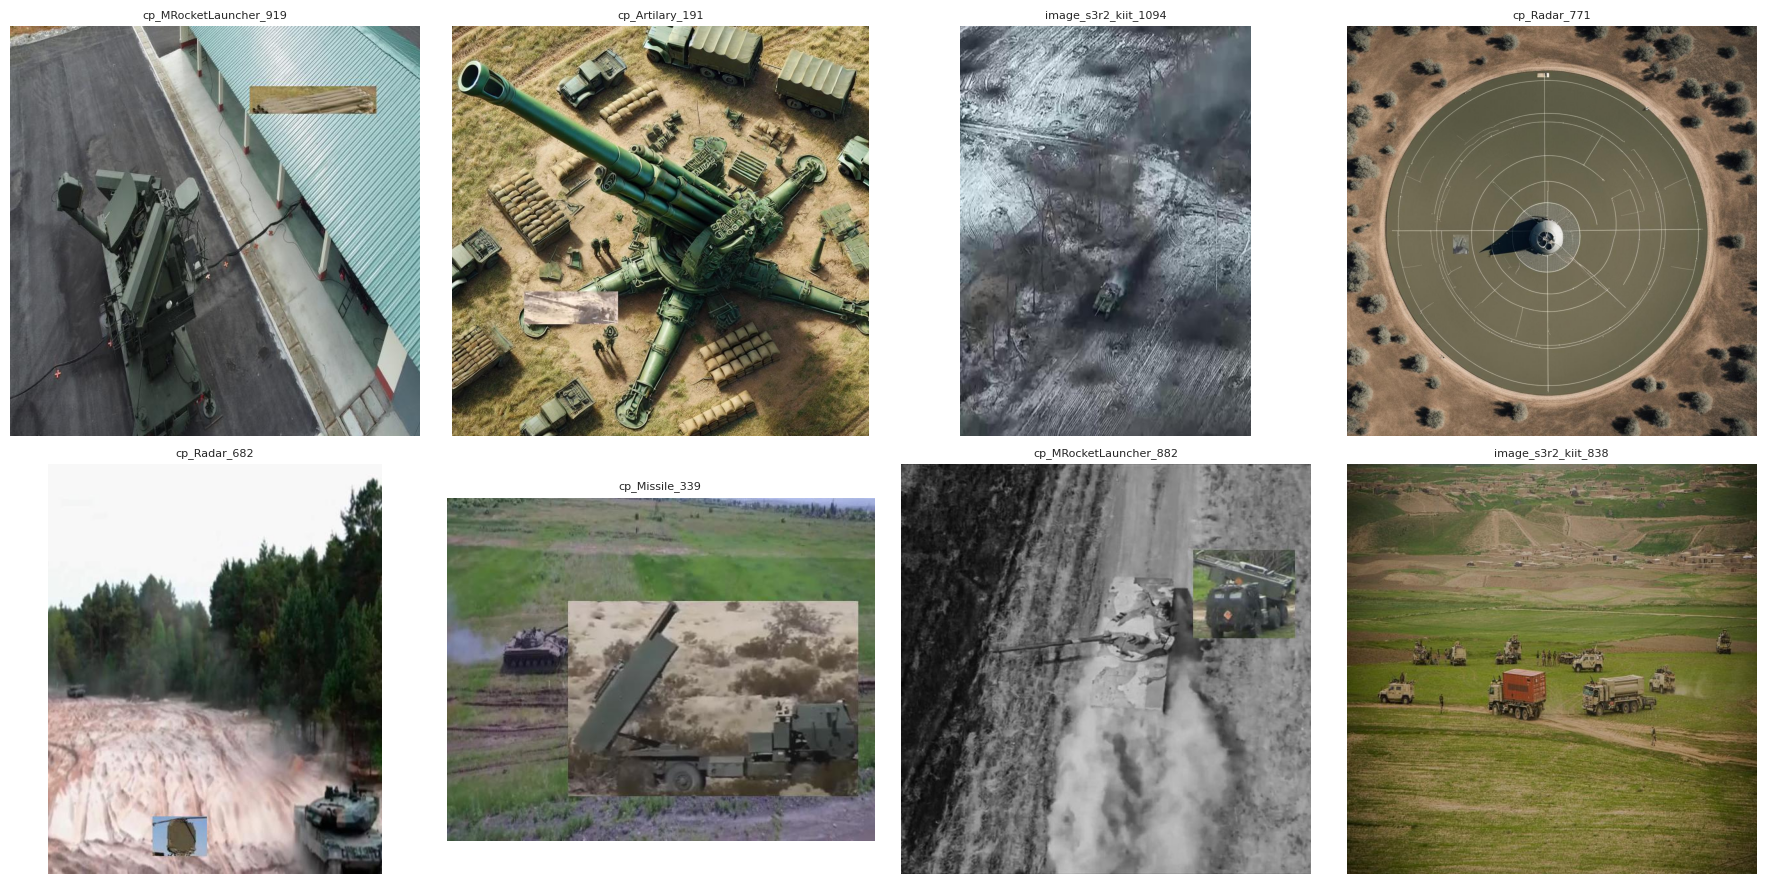

In [6]:
sample_train_paths = random.Random(SEED).sample(train_images, min(8, len(train_images)))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, p in zip(axes.flat, sample_train_paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.stem[:28], fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 4. BYOL config — third attempt: 200 epochs

Epoch budget and batch size are fixed across all four SSL methods and both baselines (fairness): here
that means `epochs=200`, `batch_size=32` per GPU (`64` total), `seed` (from the prep manifest).
`image_size=224` — BYOL evaluates the backbone four times per view pair (online + target, x2 views)

In [7]:
METHOD = "byol"
PRETRAIN_OUTPUT_DIR = f"/kaggle/working/{METHOD}_kiitmita_v3"  # v3: keeps v1 (collapsed) and v2 (30-epoch retune) checkpoints for comparison

config = PretrainConfig(
    method=METHOD,
    image_roots=[str(SSL_POOL_TRAIN_DIR)],
    output_dir=PRETRAIN_OUTPUT_DIR,
    yolo_model="yolo26n.yaml",
    epochs=200,
    batch_size=32,
    image_size=224,
    workers=2,
    seed=SEED,
    learning_rate=1e-4,
    min_learning_rate=1e-6,
    weight_decay=1e-4,
    warmup_epochs=10,
    grad_accum_steps=1,
    gradient_clip=5.0,
    amp=True,
    projection_dim=256,
    hidden_dim=1024,
    momentum=0.996,               # unchanged - already the BYOL-paper-recommended tau_base
    final_momentum=1.0,
    save_every=5,
).validate()

pd.Series({
    "model": config.yolo_model, "epochs": config.epochs, "SSL pool images": len(train_images),
    "image size": config.image_size, "batch per GPU": config.batch_size, "world size": GPU_COUNT,
    "starting momentum": config.momentum, "final momentum": config.final_momentum, "AMP": config.amp,
})

model                yolo26n.yaml
epochs                        200
SSL pool images              2377
image size                    224
batch per GPU                  32
world size                      2
starting momentum           0.996
final momentum                1.0
AMP                          True
dtype: object

## 5. Preview the augmented BYOL views before training

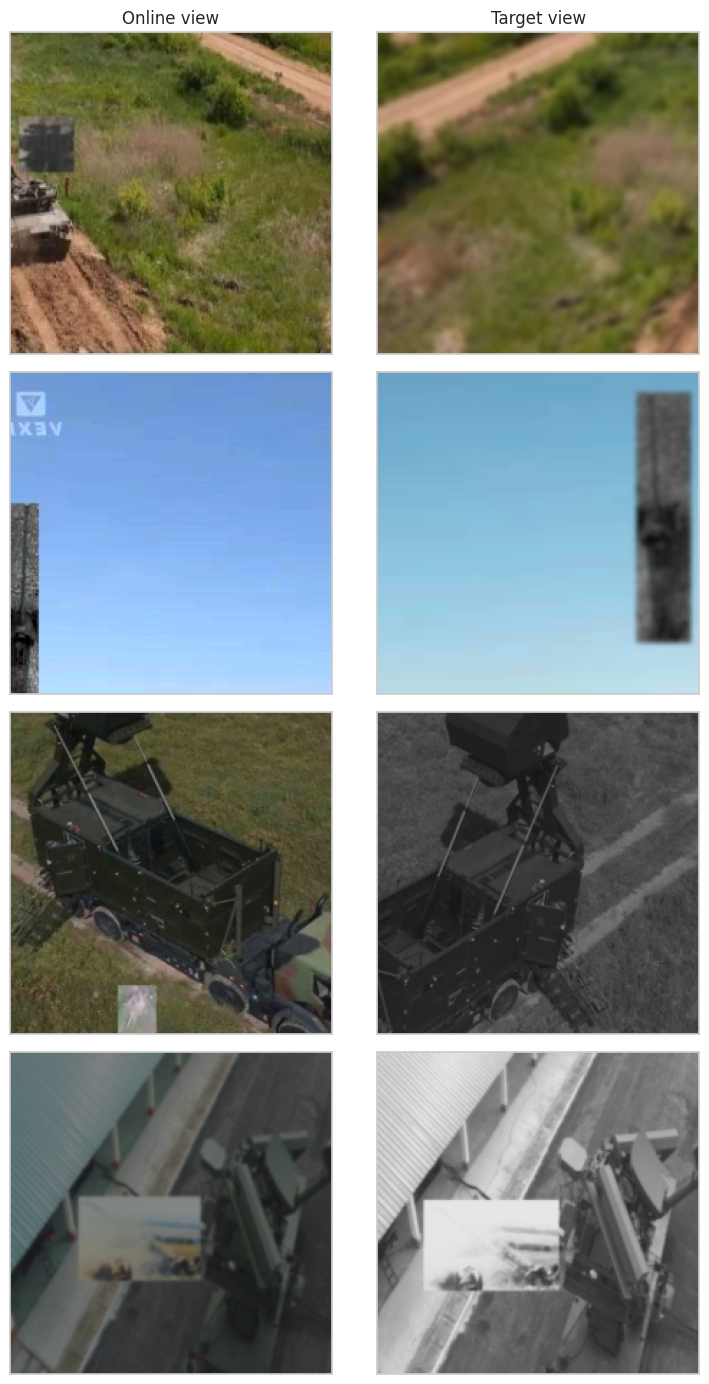

In [8]:
preview_dataset = UnlabeledImageDataset(train_images, build_transform(config))
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def display_tensor(tensor):
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)

fig, axes = plt.subplots(4, 2, figsize=(8, 14))
for row in range(4):
    view_a, view_b = preview_dataset[row]
    axes[row, 0].imshow(display_tensor(view_a))
    axes[row, 1].imshow(display_tensor(view_b))
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_title("Online view"); axes[0, 1].set_title("Target view")
plt.tight_layout(); plt.show()

## 6. Sanity check — target encoder must be frozen (updates only via EMA)

In [9]:
probe_detector = YOLO(config.yolo_model)
probe_encoder = YOLOBackboneEncoder(probe_detector.model).to(DEVICE)
with torch.inference_mode():
    feature_dim = probe_encoder(torch.zeros(1, 3, config.image_size, config.image_size, device=DEVICE)).shape[1]

byol_module = create_ssl_module(
    "byol", encoder=probe_encoder, feature_dim=feature_dim,
    hidden_dim=config.hidden_dim, projection_dim=config.projection_dim, momentum=config.momentum,
).to(DEVICE)

view_a, view_b = preview_dataset[0]
with torch.inference_mode(), torch.amp.autocast("cuda"):
    example_loss = byol_module((view_a.unsqueeze(0).to(DEVICE), view_b.unsqueeze(0).to(DEVICE)))

pd.Series({
    "feature dimensions": feature_dim, "projection dimensions": config.projection_dim,
    "example BYOL loss": float(example_loss),
    "target encoder trainable (should be False)": any(p.requires_grad for p in byol_module.target_encoder.parameters()),
})

feature dimensions                                 256
projection dimensions                              256
example BYOL loss                             2.206997
target encoder trainable (should be False)       False
dtype: object

In [10]:
del byol_module, probe_encoder, probe_detector, view_a, view_b, example_loss
torch.cuda.empty_cache()

## 7. Launch BYOL pretraining (200 epochs, distributed across both T4s)

In [11]:
training_result = launch_distributed_pretrain(
    config, num_processes=GPU_COUNT,
    config_path=f"{PRETRAIN_OUTPUT_DIR}/byol_config.yaml", check=True,
)
pd.Series({"completed": training_result.succeeded, "seconds": round(training_result.seconds, 1),
           "output directory": str(training_result.output_dir)})

BYOL 01/200: 100%|██████████| 37/37 [00:57<00:00,  1.56s/it, ema=0.99600, loss=1.7769, lr=1.03e-05]


Epoch 01 | loss=1.77799 | time=57.6s


BYOL 02/200: 100%|██████████| 37/37 [00:31<00:00,  1.18it/s, ema=0.99600, loss=0.6678, lr=2.03e-05]


Epoch 02 | loss=0.66448 | time=31.3s


BYOL 03/200: 100%|██████████| 37/37 [00:30<00:00,  1.23it/s, ema=0.99600, loss=0.2937, lr=3.03e-05]


...

BYOL 200/200:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 199 | loss=0.25072 | time=32.8s


BYOL 200/200: 100%|██████████| 37/37 [00:31<00:00,  1.19it/s, ema=1.00000, loss=0.2598, lr=1.00e-06]
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


Epoch 200 | loss=0.25287 | time=31.2s
{
  "output_dir": "/kaggle/working/byol_kiitmita_v3",
  "yolo_checkpoint": "/kaggle/working/byol_kiitmita_v3/byol_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/byol_kiitmita_v3/last_ssl.pt",
  "history_csv": "/kaggle/working/byol_kiitmita_v3/history.csv",
  "manifest_json": "/kaggle/working/byol_kiitmita_v3/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/byol_kiitmita_v3",
  "yolo_checkpoint": "/kaggle/working/byol_kiitmita_v3/byol_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/byol_kiitmita_v3/last_ssl.pt",
  "history_csv": "/kaggle/working/byol_kiitmita_v3/history.csv",
  "manifest_json": "/kaggle/working/byol_kiitmita_v3/run_manifest.json"
}


completed                                       True
seconds                                       6303.2
output directory    /kaggle/working/byol_kiitmita_v3
dtype: object

## 8. Loss and target-momentum curves

,epoch,loss,learning_rate,ema_momentum,seconds
0,1,1.777987,0.000010,0.996000,57.623449
1,2,0.664481,0.000020,0.996001,31.281493
2,3,0.304450,0.000030,0.996002,30.155155
3,4,0.300874,0.000040,0.996004,32.297482
4,5,0.246352,0.000050,0.996006,29.563784
...,...,...,...,...,...
195,196,0.248341,0.000001,0.999996,31.173386
196,197,0.248765,0.000001,0.999998,30.698600
197,198,0.249434,0.000001,0.999999,32.258783
198,199,0.250715,0.000001,1.000000,32.836388


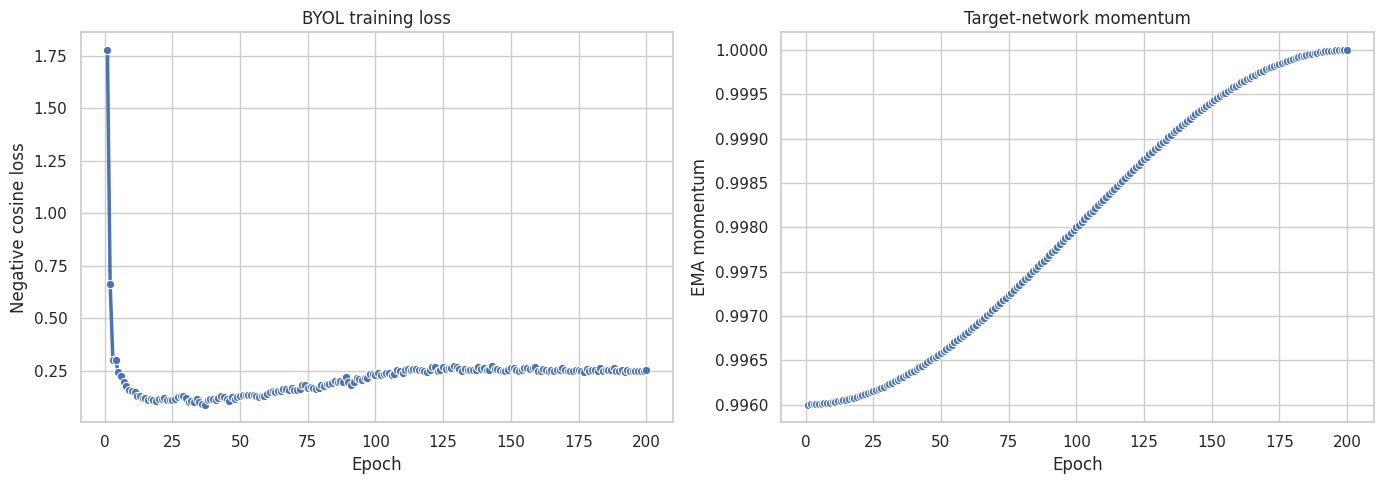

In [12]:
history = pd.read_csv(f"{PRETRAIN_OUTPUT_DIR}/history.csv")
display(history.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=history, x="epoch", y="loss", marker="o", linewidth=2.5, ax=axes[0])
sns.lineplot(data=history, x="epoch", y="ema_momentum", marker="o", linewidth=2.5, ax=axes[1])
axes[0].set_title(f"{METHOD.upper()} training loss"); axes[0].set_ylabel("Negative cosine loss")
axes[1].set_title("Target-network momentum"); axes[1].set_ylabel("EMA momentum")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

## 9. Locate the exported checkpoints

In [13]:
manifest = json.loads((Path(PRETRAIN_OUTPUT_DIR) / "run_manifest.json").read_text())
YOLO_CHECKPOINT = Path(manifest["outputs"]["yolo_checkpoint"])
SSL_CHECKPOINT = Path(manifest["outputs"]["ssl_checkpoint"])

pd.Series({
    "initialization": manifest["initialization"], "unlabeled images": manifest["unlabeled_images"],
    "world size": manifest["world_size"], "best loss": manifest["best_loss"],
    "YOLO checkpoint": str(YOLO_CHECKPOINT), "full BYOL checkpoint": str(SSL_CHECKPOINT),
})

initialization          random initialization; strict label-free SSL p...
unlabeled images                                                     2377
world size                                                              2
best loss                                                         0.09035
YOLO checkpoint         /kaggle/working/byol_kiitmita_v3/byol_pretrain...
full BYOL checkpoint         /kaggle/working/byol_kiitmita_v3/last_ssl.pt
dtype: object

## 10. Extract validation features

Embed every validation image with the trained backbone. Validation images are always 100% raw (never
copy-paste-augmented), so this is a clean generalisation check.


In [14]:
import torchvision.transforms.v2 as v2

detector = YOLO(str(YOLO_CHECKPOINT))
encoder = YOLOBackboneEncoder(detector.model).to(DEVICE).eval()
infer_tf = v2.Compose([v2.Resize((config.image_size, config.image_size)), v2.ToImage(),
                        v2.ToDtype(torch.float32, scale=True), v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

EMBEDDING_LIMIT = 200
selected_paths = val_images if len(val_images) <= EMBEDDING_LIMIT else random.Random(SEED).sample(val_images, EMBEDDING_LIMIT)

feats, paths = [], []
with torch.inference_mode():
    for p in tqdm(selected_paths, desc="Embedding val images"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(encoder(x).flatten(1), dim=1)
        feats.append(feat.squeeze(0).cpu().numpy())
        paths.append(p)

feature_matrix = np.stack(feats)
pd.Series({
    "images": float(len(feature_matrix)),
    "feature dimensions": float(feature_matrix.shape[1]),
    "feature norm mean": float(np.linalg.norm(feature_matrix, axis=1).mean()),
})

Embedding val images:   0%|          | 0/164 [00:00<?, ?it/s]

images                164.0
feature dimensions    256.0
feature norm mean       1.0
dtype: float64

## 11. t-SNE of validation embeddings, coloured by dominant class

Val labels exist on disk (only the SSL-pool/train labels are unused for pretraining) — colour by each
image's dominant class using them, so this plot actually shows colour variation.


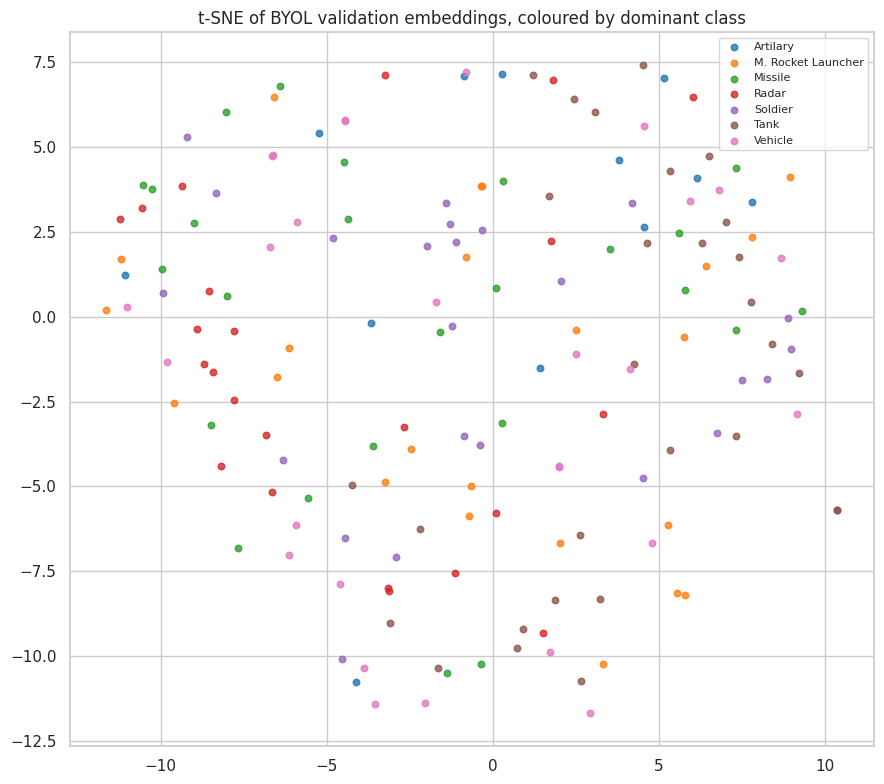

In [15]:
def dominant_class_for_stem(stem, labels_dir):
    lbl_path = Path(labels_dir) / f"{stem}.txt"
    counts = Counter()
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return CLASS_NAMES[counts.most_common(1)[0][0]] if counts else "No Label"

val_labels_dir = RESPLIT_ROOT / "val" / "labels"
point_classes = [dominant_class_for_stem(p.stem, val_labels_dir) for p in paths]

perplexity = min(30.0, max(2.0, (len(feature_matrix) - 1) / 3))
tsne_xy = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(9, 8))
palette = sns.color_palette("tab10", n_colors=len(set(point_classes)))
for color, cls in zip(palette, sorted(set(point_classes))):
    idx = [i for i, c in enumerate(point_classes) if c == cls]
    ax.scatter(tsne_xy[idx, 0], tsne_xy[idx, 1], label=cls, s=22, alpha=0.8, color=color)
ax.legend(fontsize=8, loc="best"); ax.set_title(f"t-SNE of {METHOD.upper()} validation embeddings, coloured by dominant class")
plt.tight_layout(); plt.show()

## 12. Nearest-neighbour retrieval

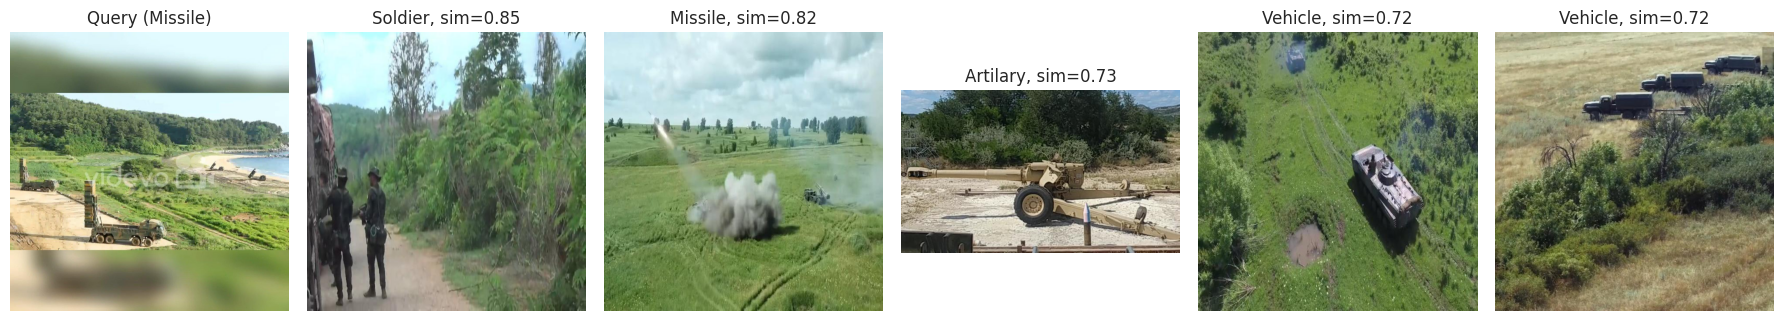

In [16]:
sims = cosine_similarity(feature_matrix)
QUERY_INDEX = 0
NEIGHBOR_COUNT = min(5, len(feature_matrix) - 1)
neighbour_idx = np.argsort(-sims[QUERY_INDEX])[1:NEIGHBOR_COUNT + 1]

fig, axes = plt.subplots(1, NEIGHBOR_COUNT + 1, figsize=(3 * (NEIGHBOR_COUNT + 1), 3.2))
axes[0].imshow(Image.open(paths[QUERY_INDEX]))
axes[0].set_title(f"Query ({point_classes[QUERY_INDEX]})"); axes[0].axis("off")
for ax, idx in zip(axes[1:], neighbour_idx):
    ax.imshow(Image.open(paths[idx])); ax.set_title(f"{point_classes[idx]}, sim={sims[QUERY_INDEX, idx]:.2f}"); ax.axis("off")
plt.tight_layout(); plt.show()

## 13. Shortcut-learning check — raw vs. copy-paste synthetic, on the TRAIN pool

This check needs images that actually include copy-paste synthetics, so it runs on the **train** pool
specifically (not validation, which is always 100% raw and would show only one colour here).


Embedding train-pool images:   0%|          | 0/300 [00:00<?, ?it/s]

Raw: 155 | Copy-paste synthetic: 145


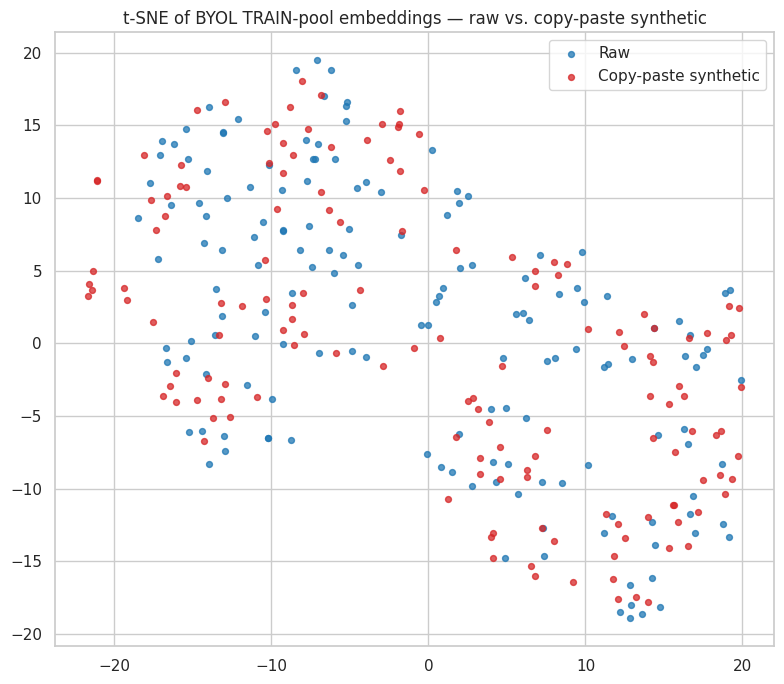

In [17]:
TRAIN_DIAGNOSTIC_LIMIT = 300
train_stem_set_raw = set(stems_train)
train_sample_paths = train_images if len(train_images) <= TRAIN_DIAGNOSTIC_LIMIT else random.Random(SEED).sample(train_images, TRAIN_DIAGNOSTIC_LIMIT)

train_feats, train_is_synthetic = [], []
with torch.inference_mode():
    for p in tqdm(train_sample_paths, desc="Embedding train-pool images"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(encoder(x).flatten(1), dim=1)
        train_feats.append(feat.squeeze(0).cpu().numpy())
        train_is_synthetic.append(p.stem not in train_stem_set_raw)  # cp_*/cp20_* stems are synthetic

train_feature_matrix = np.stack(train_feats)
print("Raw:", train_is_synthetic.count(False), "| Copy-paste synthetic:", train_is_synthetic.count(True))

perplexity_train = min(30.0, max(2.0, (len(train_feature_matrix) - 1) / 3))
tsne_train_xy = TSNE(n_components=2, random_state=SEED, perplexity=perplexity_train).fit_transform(train_feature_matrix)

fig, ax = plt.subplots(figsize=(8, 7))
for flag, label, color in [(False, "Raw", "tab:blue"), (True, "Copy-paste synthetic", "tab:red")]:
    idx = [i for i, s in enumerate(train_is_synthetic) if s == flag]
    ax.scatter(tsne_train_xy[idx, 0], tsne_train_xy[idx, 1], label=label, s=18, alpha=0.75, c=color)
ax.legend(); ax.set_title(f"t-SNE of {METHOD.upper()} TRAIN-pool embeddings — raw vs. copy-paste synthetic")
plt.tight_layout(); plt.show()

## 14. Quantitative collapse diagnostics — beyond eyeballing one query

Two rigorous, standard SSL diagnostics, computed over the validation embedding batch. This is the test
that should settle whether the first (and second) BYOL attempts actually collapsed, rather than relying
only on the single-query nearest-neighbour panel above.

- **Pairwise similarity distribution**: histogram of every off-diagonal cosine similarity. A collapsed
  encoder produces a sharp spike near 1.0 regardless of image content; a healthy encoder produces a much
  wider spread.
- **Effective rank (singular-value spectrum)**: SVD of the embedding matrix. A collapsed encoder's
  embeddings live in a near-1-dimensional subspace; a healthy encoder uses many more directions.


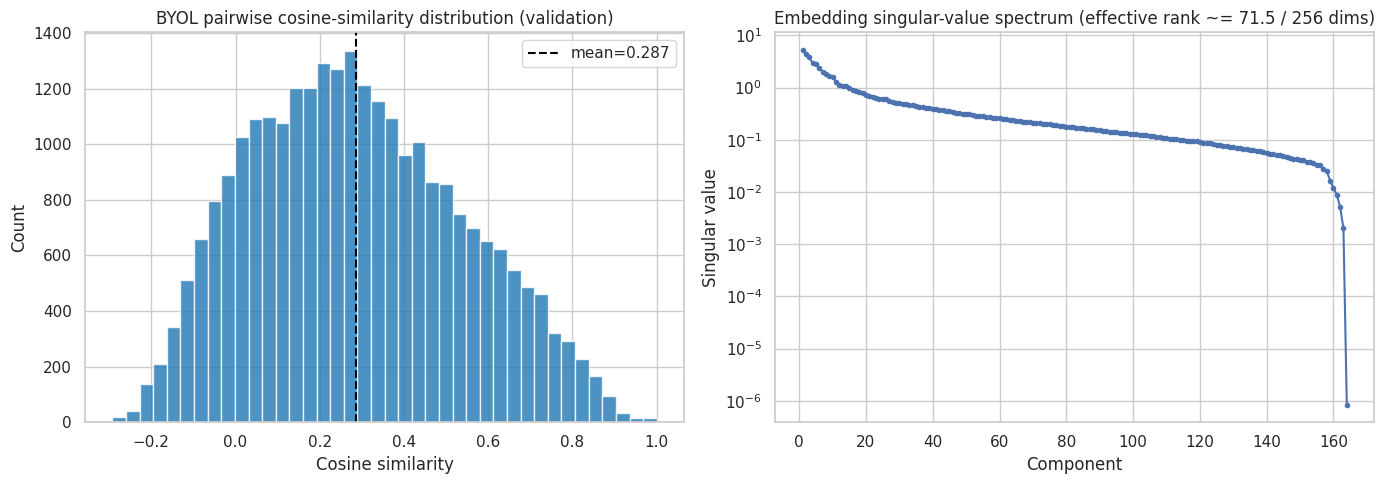

mean pairwise similarity                                        0.287
std pairwise similarity                                        0.2514
effective rank                                                  71.51
embedding dimensionality                                          256
collapse read               no strong collapse signature by this test
dtype: object

In [18]:
pairwise_sims = cosine_similarity(feature_matrix)
off_diagonal = pairwise_sims[~np.eye(len(pairwise_sims), dtype=bool)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(off_diagonal, bins=40, color="tab:blue", alpha=0.8)
axes[0].axvline(off_diagonal.mean(), color="black", linestyle="--", label=f"mean={off_diagonal.mean():.3f}")
axes[0].set_title(f"{METHOD.upper()} pairwise cosine-similarity distribution (validation)")
axes[0].set_xlabel("Cosine similarity"); axes[0].set_ylabel("Count"); axes[0].legend()

singular_values = np.linalg.svd(feature_matrix - feature_matrix.mean(axis=0), compute_uv=False)
normalized_sv = singular_values / singular_values.sum()
effective_rank = float(np.exp(-(normalized_sv * np.log(normalized_sv + 1e-12)).sum()))
axes[1].plot(range(1, len(singular_values) + 1), singular_values, marker="o", markersize=3)
axes[1].set_title(f"Embedding singular-value spectrum (effective rank ~= {effective_rank:.1f} / {feature_matrix.shape[1]} dims)")
axes[1].set_xlabel("Component"); axes[1].set_ylabel("Singular value"); axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

pd.Series({
    "mean pairwise similarity": round(float(off_diagonal.mean()), 4),
    "std pairwise similarity": round(float(off_diagonal.std()), 4),
    "effective rank": round(effective_rank, 2),
    "embedding dimensionality": feature_matrix.shape[1],
    "collapse read": ("LIKELY COLLAPSED - similarities tightly clustered near 1.0 and/or effective rank very low"
                       if off_diagonal.mean() > 0.9 and off_diagonal.std() < 0.05
                       else "no strong collapse signature by this test"),
})

## 15. Exercise — momentum ablation ($\tau_{base}=0.99$)

BYOL has no temperature parameter (that is a contrastive-method concept). Its closest analog is the
**target-network momentum** — how slowly the target network's EMA weights follow the online network.
The main run above used `momentum=0.996` (the BYOL-paper default, already investigated across three
config attempts). This exercise trains a shorter run with a **lower** momentum, `momentum=0.99`, and
compares its loss/momentum curves, t-SNE, and nearest neighbours against the main run — same seed, same
`selected_paths` validation images, for a fair comparison.

**Prediction before running:** a lower momentum means the target network updates *faster* per step
(`target = momentum * target + (1 - momentum) * online`, so a smaller `momentum` weights the fast-moving
online network more heavily in every EMA update). This makes the target track the online network more
closely, **weakening the online-target asymmetry that is BYOL's main defence against collapse** — the
model has less structural protection against the predictor trivially matching a near-identical target.
Expect `momentum=0.99` to show *more* collapse-like behaviour (higher pairwise similarity, lower
effective rank) than the main run's `momentum=0.996`, not less.

**Honest caveat:** this exercise run uses 50 epochs, far fewer than the main run's 200 — so any
difference observed is a mix of the momentum effect and the shorter training, not momentum alone.


In [19]:
from dataclasses import replace

momentum_exercise_config = replace(
    config,
    momentum=0.99,
    epochs=50,
    warmup_epochs=3,
    output_dir=f"/kaggle/working/{METHOD}_kiitmita_momentum099",
).validate()

pd.Series({
    "momentum": momentum_exercise_config.momentum,
    "final_momentum": momentum_exercise_config.final_momentum,
    "epochs": momentum_exercise_config.epochs,
    "warmup_epochs": momentum_exercise_config.warmup_epochs,
    "output directory": momentum_exercise_config.output_dir,
})

momentum                                                 0.99
final_momentum                                            1.0
epochs                                                     50
warmup_epochs                                               3
output directory    /kaggle/working/byol_kiitmita_momentum099
dtype: object

In [20]:
momentum_exercise_result = launch_distributed_pretrain(
    momentum_exercise_config, num_processes=GPU_COUNT,
    config_path=f"{momentum_exercise_config.output_dir}/byol_momentum099_config.yaml", check=True,
)

BYOL 01/50: 100%|██████████| 37/37 [00:54<00:00,  1.48s/it, ema=0.99001, loss=1.3587, lr=3.42e-05]


Epoch 01 | loss=1.36040 | time=54.8s


BYOL 02/50: 100%|██████████| 37/37 [00:30<00:00,  1.23it/s, ema=0.99004, loss=0.1180, lr=6.76e-05]


Epoch 02 | loss=0.11686 | time=30.2s


BYOL 04/50:   0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch 48 | loss=0.17301 | time=30.8s


BYOL 50/50:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 49 | loss=0.18758 | time=31.4s


BYOL 50/50: 100%|██████████| 37/37 [00:30<00:00,  1.22it/s, ema=1.00000, loss=0.1800, lr=1.00e-06]
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


Epoch 50 | loss=0.17712 | time=30.4s
{
  "output_dir": "/kaggle/working/byol_kiitmita_momentum099",
  "yolo_checkpoint": "/kaggle/working/byol_kiitmita_momentum099/byol_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/byol_kiitmita_momentum099/last_ssl.pt",
  "history_csv": "/kaggle/working/byol_kiitmita_momentum099/history.csv",
  "manifest_json": "/kaggle/working/byol_kiitmita_momentum099/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/byol_kiitmita_momentum099",
  "yolo_checkpoint": "/kaggle/working/byol_kiitmita_momentum099/byol_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/byol_kiitmita_momentum099/last_ssl.pt",
  "history_csv": "/kaggle/working/byol_kiitmita_momentum099/history.csv",
  "manifest_json": "/kaggle/working/byol_kiitmita_momentum099/run_manifest.json"
}


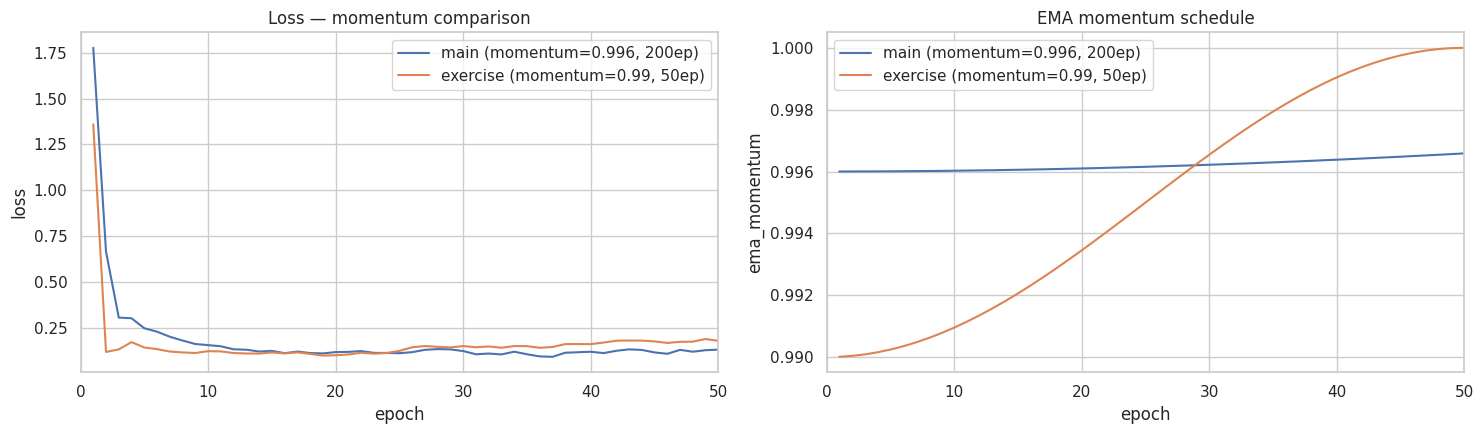

In [21]:
momentum_exercise_history = pd.read_csv(f"{momentum_exercise_config.output_dir}/history.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.lineplot(data=history, x="epoch", y="loss", label="main (momentum=0.996, 200ep)", ax=axes[0])
sns.lineplot(data=momentum_exercise_history, x="epoch", y="loss", label="exercise (momentum=0.99, 50ep)", ax=axes[0])
axes[0].set_title("Loss — momentum comparison"); axes[0].set_xlim(0, 50)

sns.lineplot(data=history, x="epoch", y="ema_momentum", label="main (momentum=0.996, 200ep)", ax=axes[1])
sns.lineplot(data=momentum_exercise_history, x="epoch", y="ema_momentum", label="exercise (momentum=0.99, 50ep)", ax=axes[1])
axes[1].set_title("EMA momentum schedule"); axes[1].set_xlim(0, 50)
plt.tight_layout(); plt.show()

Feature extraction on the *same* validation images as the main run, for a fair comparison.

In [22]:
momentum_exercise_manifest = json.loads((Path(momentum_exercise_config.output_dir) / "run_manifest.json").read_text())
MOMENTUM_EXERCISE_YOLO_CHECKPOINT = Path(momentum_exercise_manifest["outputs"]["yolo_checkpoint"])

momentum_exercise_detector = YOLO(str(MOMENTUM_EXERCISE_YOLO_CHECKPOINT))
momentum_exercise_encoder = YOLOBackboneEncoder(momentum_exercise_detector.model).to(DEVICE).eval()

momentum_exercise_feats = []
with torch.inference_mode():
    for p in tqdm(selected_paths, desc="Embedding val images (momentum=0.99)"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(momentum_exercise_encoder(x).flatten(1), dim=1)
        momentum_exercise_feats.append(feat.squeeze(0).cpu().numpy())
momentum_exercise_feature_matrix = np.stack(momentum_exercise_feats)

Embedding val images (momentum=0.99):   0%|          | 0/164 [00:00<?, ?it/s]

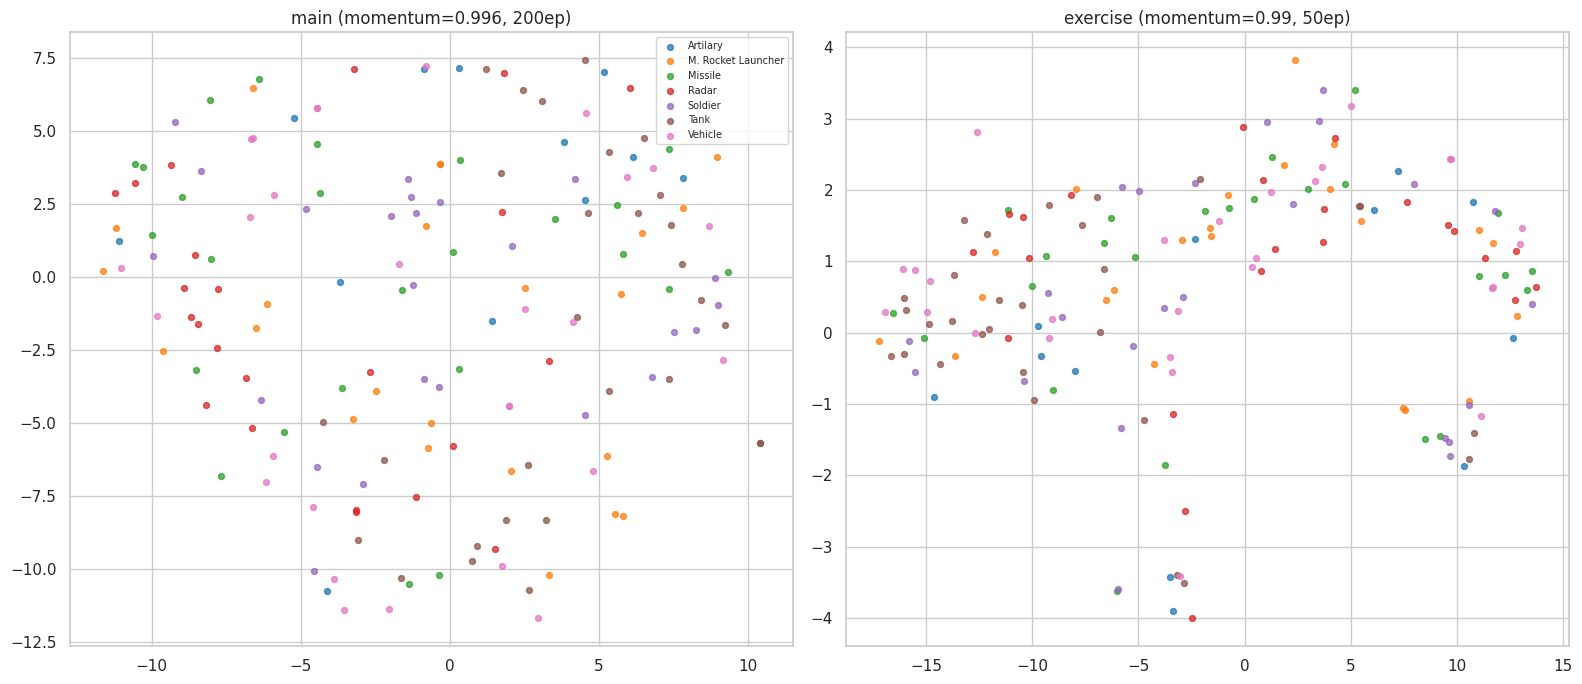

In [23]:
tsne_main = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(feature_matrix)
tsne_momentum_exercise = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(momentum_exercise_feature_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, xy, title in [(axes[0], tsne_main, "main (momentum=0.996, 200ep)"),
                       (axes[1], tsne_momentum_exercise, "exercise (momentum=0.99, 50ep)")]:
    for color, cls in zip(palette, sorted(set(point_classes))):
        idx = [i for i, c in enumerate(point_classes) if c == cls]
        ax.scatter(xy[idx, 0], xy[idx, 1], label=cls, s=18, alpha=0.75, color=color)
    ax.set_title(title)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

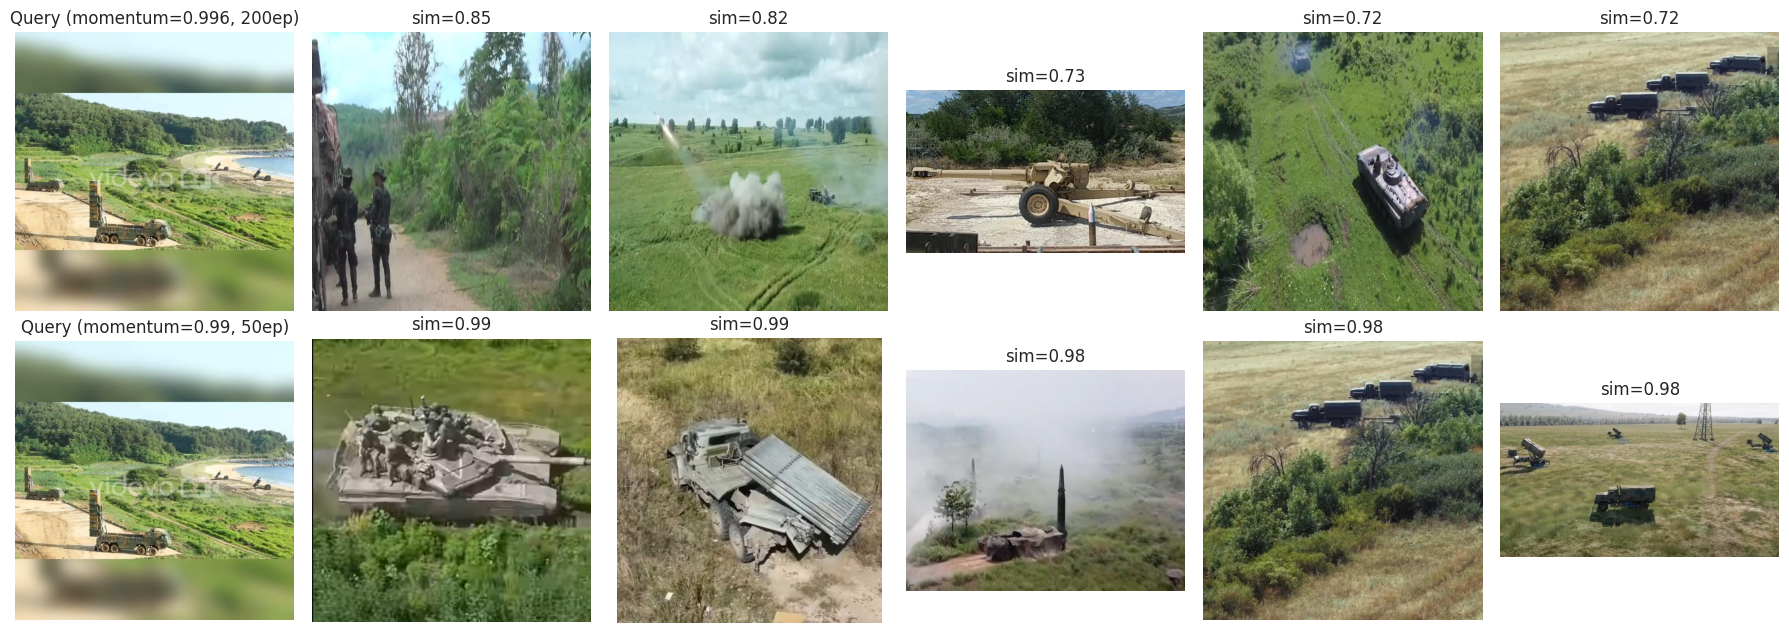

In [24]:
sims_main = cosine_similarity(feature_matrix)
sims_momentum_exercise = cosine_similarity(momentum_exercise_feature_matrix)

fig, axes = plt.subplots(2, NEIGHBOR_COUNT + 1, figsize=(3 * (NEIGHBOR_COUNT + 1), 6.4))
for row, (sims, title) in enumerate([(sims_main, "momentum=0.996, 200ep"), (sims_momentum_exercise, "momentum=0.99, 50ep")]):
    neighbour_idx = np.argsort(-sims[QUERY_INDEX])[1:NEIGHBOR_COUNT + 1]
    axes[row, 0].imshow(Image.open(paths[QUERY_INDEX])); axes[row, 0].set_title(f"Query ({title})"); axes[row, 0].axis("off")
    for col, idx in enumerate(neighbour_idx, start=1):
        axes[row, col].imshow(Image.open(paths[idx])); axes[row, col].set_title(f"sim={sims[QUERY_INDEX, idx]:.2f}"); axes[row, col].axis("off")
plt.tight_layout(); plt.show()

Numeric answer to the prediction, using the same collapse-diagnostic test as the main run.

In [25]:
def collapse_stats(fm):
    sims = cosine_similarity(fm)
    off = sims[~np.eye(len(sims), dtype=bool)]
    sv = np.linalg.svd(fm - fm.mean(axis=0), compute_uv=False)
    p = sv / sv.sum()
    eff_rank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
    return off.mean(), off.std(), eff_rank

mean_main, std_main, rank_main = collapse_stats(feature_matrix)
mean_ex, std_ex, rank_ex = collapse_stats(momentum_exercise_feature_matrix)

pd.DataFrame({
    "main (momentum=0.996, 200ep)": [mean_main, std_main, rank_main],
    "exercise (momentum=0.99, 50ep)": [mean_ex, std_ex, rank_ex],
}, index=["mean pairwise similarity", "std pairwise similarity", "effective rank"]).round(4)

,"main (momentum=0.996, 200ep)","exercise (momentum=0.99, 50ep)"
mean pairwise similarity,0.2870,0.3302
std pairwise similarity,0.2514,0.4952
effective rank,71.5069,35.8231


### Markdown — was the prediction correct?

*(Fill in after running: did `momentum=0.99` produce a higher mean pairwise similarity and/or a lower
effective rank than `momentum=0.996`, consistent with weaker online-target asymmetry increasing collapse
risk? Remember the epoch-count confound (50 vs. 200) applies here too — report as suggestive, not as
fully isolated proof.)*


## 16. Publish the checkpoint for Notebook 2b

Run *Save & Run All (Commit)*, then attach this notebook's output as an input to `group02-partB-02b-byol-detect`.

In [26]:
print("Attach this notebook as a Kaggle input to Notebook 2b.")
print("SSL checkpoint:", SSL_CHECKPOINT)
print("YOLO checkpoint:", YOLO_CHECKPOINT)

Attach this notebook as a Kaggle input to Notebook 2b.
SSL checkpoint: /kaggle/working/byol_kiitmita_v3/last_ssl.pt
YOLO checkpoint: /kaggle/working/byol_kiitmita_v3/byol_pretrained_yolo26n.pt
